<font size="18">WEBDATASET READER EXAMPLE </font>

This application demonstrates how to use data stored in the WebDataset format in rocAL.

<font size="12"> Common Code </font>

In [52]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
import random
import numpy as np
from amd.rocal.plugin.pytorch import ROCALClassificationIterator
from amd.rocal.pipeline import Pipeline
import amd.rocal.fn as fn
import amd.rocal.types as types
import matplotlib.pyplot as plt
import torch
%matplotlib inline

<font size= "12" >Configuring rocAL pipeline </font>

Configure the pipeline parameters as required by the user.

In [53]:
wds_data = "/media/audio_goldens/test/MIVisionX-data/rocal_data/web_dataset/"
rocal_cpu = True
device = "cpu" 
batch_size =  1
num_threads = 1
device_id = 0
random_seed = random.SystemRandom().randint(0, 2**32 - 1)
crop=300
local_rank = 0
world_size = 1
color_format=types.RGB

In [ ]:
webdataset_pipeline = Pipeline(batch_size=batch_size, num_threads=num_threads, device_id=device_id, seed=random_seed, rocal_cpu=device, tensor_dtype = types.UINT8, )

<font size="12">Webdataset pipeline </font>

Here the webdataset reader is used followed by the webdataset decoder. In this pipeline, cascaded augmentations are added on the decoded images.<br>crop mirror normalize augmentation outputs are returned using set_outputs

In [ ]:
with webdataset_pipeline:
        img_raw = fn.readers.webdataset(
        path=wds_data, ext=[{'jpg', 'cls'}],  missing_components_behavior=types.SKIP
        )
        img = fn.decoders.image(img_raw, file_root=wds_data, output_type=color_format,max_decoded_width=500, max_decoded_height=500)
        resize_outputs = fn.resize(img, resize_width=300, resize_height=300)
        output = fn.crop_mirror_normalize(resize_outputs,
                                          output_layout=types.NHWC,
                                          output_dtype=types.UINT8,
                                          crop=(224, 224),
                                          mean=[0.0, 0.0, 0.0],
                                          std=[1.0, 1.0, 1.0])
        webdataset_pipeline.set_outputs(output)

In [56]:
webdataset_pipeline.build()
data_loader = ROCALClassificationIterator(webdataset_pipeline, auto_reset=True)

<font size ="12">Visualizing  outputs</font>

The output of augmented images are displayed using imshow()

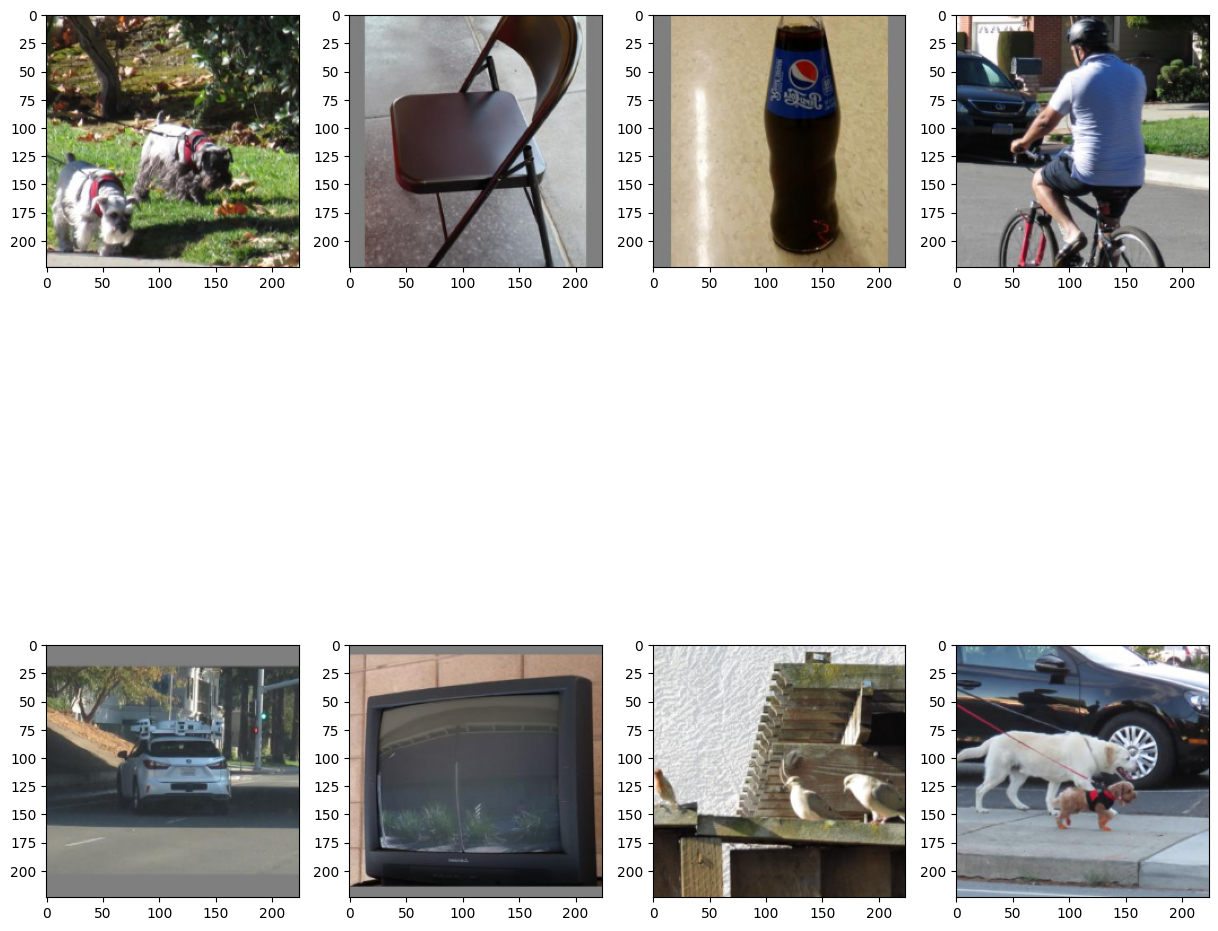

In [57]:
cnt = 0
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15,15))
row = 0
col = 0
for i, it in enumerate(data_loader, 0):
    for img in it[0]:
        img[0] = img[0].to(torch.uint8)
        axes[row, col].imshow(img[0])
        cnt += 1
        row += 1
        if(row == 2):
            row = 0
            col += 1
        if(col == 4):
            col = 0
data_loader.reset()